#INTRO

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 50px 40px; border-radius: 20px; margin-bottom: 30px;">
  <h1 style="color: #e94560; font-size: 2.8em; font-weight: 900; margin: 0; text-shadow: 2px 2px 10px rgba(233,69,96,0.5);">🎯 Customer Segmentation</h1>
  <h2 style="color: #a8dadc; font-size: 1.6em; margin: 10px 0 20px 0; font-weight: 400;">K-Means Clustering — Full Pipeline</h2>
  <hr style="border: 2px solid #e94560; width: 60px; margin: 0 0 20px 0;">
  <p style="color: #ccc; font-size: 1em; max-width: 700px; line-height: 1.8;">
    Notebook ini mencakup pipeline lengkap mulai dari <strong style='color:#e94560'>Exploratory Data Analysis (EDA)</strong>,
    <strong style='color:#e94560'>Anomaly Detection</strong>, <strong style='color:#e94560'>Preprocessing</strong>,
    <strong style='color:#e94560'>K-Means Modeling</strong>, hingga <strong style='color:#e94560'>Post-Processing & Business Insights</strong>.
  </p>
  <div style="margin-top: 25px; display: flex; gap: 10px; flex-wrap: wrap;">
    <span style="background:#e94560; color:white; padding:6px 14px; border-radius:20px; font-size:0.85em;">📊 53,503 Rows</span>
    <span style="background:#0f3460; border:1px solid #a8dadc; color:#a8dadc; padding:6px 14px; border-radius:20px; font-size:0.85em;">🔢 20 Features</span>
    <span style="background:#0f3460; border:1px solid #a8dadc; color:#a8dadc; padding:6px 14px; border-radius:20px; font-size:0.85em;">⚙️ K-Means Clustering</span>
    <span style="background:#0f3460; border:1px solid #a8dadc; color:#a8dadc; padding:6px 14px; border-radius:20px; font-size:0.85em;">🏢 Insurance Domain</span>
  </div>
</div>

<div style="background:#1e1e2e; border-left: 5px solid #e94560; padding: 20px 25px; border-radius: 10px; margin-bottom: 20px;">
<h2 style="color:#e94560; margin-top:0;">📦 Step 0 — Import Libraries</h2>
<p style="color:#ccc;">Semua library yang diperlukan untuk analisis end-to-end.</p>
</div>

In [ ]:
# ── Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisasi
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import FancyBboxPatch

# ── Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# ── Modeling
from sklearn.cluster import KMeans

# ── Evaluasi
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ── Anomali
from scipy import stats

# ── Styling default
PALETTE     = ['#e94560', '#a8dadc', '#f4a261', '#06d6a0', '#7b2d8b']
DARK_BG     = '#1a1a2e'
CARD_BG     = '#16213e'


print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


<div style="background:#1e1e2e; border-left: 5px solid #a8dadc; padding: 20px 25px; border-radius: 10px; margin: 20px 0;">
<h2 style="color:#a8dadc; margin-top:0;">📂 Step 1 — Load Data & Overview</h2>
<p style="color:#ccc;">Load dataset dan lihat gambaran awal: shape, dtypes, sample rows, dan missing values.</p>
</div>

In [ ]:
df = pd.read_csv("/content/customer_segmentation_data.csv")

print('=' * 60)
print(f'  📊  DATASET OVERVIEW')
print('=' * 60)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print('=' * 60)
df.head(10)

  📊  DATASET OVERVIEW
  Rows    : 53,503
  Columns : 20


,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2
5,60937,41,Female,Separated,Master's Degree,Uttar Pradesh,Nurse,87188,policy5,9/19/2020,Chat,policy1,570757,1106,Individual,Text,Text,Afternoon,English,Segment4
6,37676,55,Male,Single,Bachelor's Degree,Rajasthan,Manager,94891,policy3,07-04-2021,Chat,policy2,604069,3661,Group,In-Person Meeting,Text,Weekends,Mandarin,Segment5
7,54100,35,Male,Married,Master's Degree,Himachal Pradesh,Artist,61003,policy1,11-01-2021,Phone,policy3,418997,1148,Business,Email,Phone,Morning,English,Segment5
8,30476,43,Female,Single,Doctorate,Manipur,Salesperson,116249,policy1,9/20/2020,Mobile App,policy4,319423,2612,Business,In-Person Meeting,Text,Weekends,Mandarin,Segment2
9,39071,32,Female,Single,Master's Degree,Gujarat,Artist,49083,policy3,4/24/2020,Phone,policy1,701577,4595,Group,Phone,Email,Weekends,English,Segment2


#Identify Data

Pada tahap ini dilakukan identifikasi terhadap permasalahan yang akan diselesaikan menggunakan pendekatan machine learning. Berdasarkan deskripsi dataset yang diperoleh dari Kaggle, data yang digunakan berisi informasi pelanggan yang mencakup atribut demografis, transaksi, dan perilaku.

Permasalahan utama dalam penelitian ini adalah bagaimana mengelompokkan (segmentasi) pelanggan ke dalam beberapa kelompok (cluster) berdasarkan karakteristik yang dimiliki, tanpa menggunakan label yang telah tersedia pada dataset. Meskipun dataset memiliki label, dalam konteks ini label tersebut tidak digunakan karena pendekatan yang diterapkan adalah unsupervised learning, yaitu clustering.

Segmentasi pelanggan menjadi penting karena:
- Membantu memahami pola dan karakteristik pelanggan
- Mengidentifikasi kelompok pelanggan dengan nilai tinggi (high-value customers)
- Mendukung strategi pemasaran yang lebih tepat sasaran
- Meningkatkan efektivitas kampanye marketing

Metode yang digunakan untuk menyelesaikan permasalahan ini adalah **K-Means Clustering**, yang bertujuan untuk membagi data pelanggan ke dalam beberapa cluster berdasarkan kemiripan fitur.

Tujuan penelitian ini adalah:
1. Mengelompokkan pelanggan ke dalam beberapa cluster berdasarkan data yang tersedia
2. Menganalisis karakteristik dari masing-masing cluster
3. Memberikan insight yang dapat digunakan untuk strategi bisnis atau pemasaran

#Instrumen Data

Pada tahap ini dilakukan penentuan data yang akan digunakan serta perancangan fitur yang relevan untuk proses clustering.

Karena metode yang digunakan adalah unsupervised learning (K-Means Clustering), maka tidak diperlukan label sebagai target. Oleh karena itu, kolom `Segmentation Group` akan dihapus agar tidak mempengaruhi proses pengelompokan.

**Fitur yang digunakan:**
- Data demografis: Age, Gender, Marital Status
- Data transaksi: Income Level, Coverage Amount, Premium Amount

**Transformasi yang akan dilakukan:**
- Menghapus kolom ID dan label (Customer ID, Purchase History, Segmentation Group) dan fitur lainnya yang tidak digunakan
- Label Encoding pada fitur kategorikal
- StandardScaler untuk normalisasi fitur numerik

'Age', 'Income Level', 'Coverage Amount', 'Premium Amount','Gender', 'Marital Status'

#Collect Data

Pada tahap ini dilakukan proses pengumpulan data yang akan digunakan dalam analisis clustering. Dataset diperoleh dari platform Kaggle, berisi informasi pelanggan asuransi yang telah dianonimkan.

- **Platform:** Kaggle
- **Jenis data:** Customer Segmentation Dataset
- **Format:** CSV (Comma-Separated Values)
- **Jumlah record:** 53.503 baris, 20 kolom

#Prepare Data - EDA

In [ ]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned         

In [ ]:
df.describe()

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


In [ ]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values')

=== Missing Values ===
Tidak ada missing values


In [ ]:
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 0


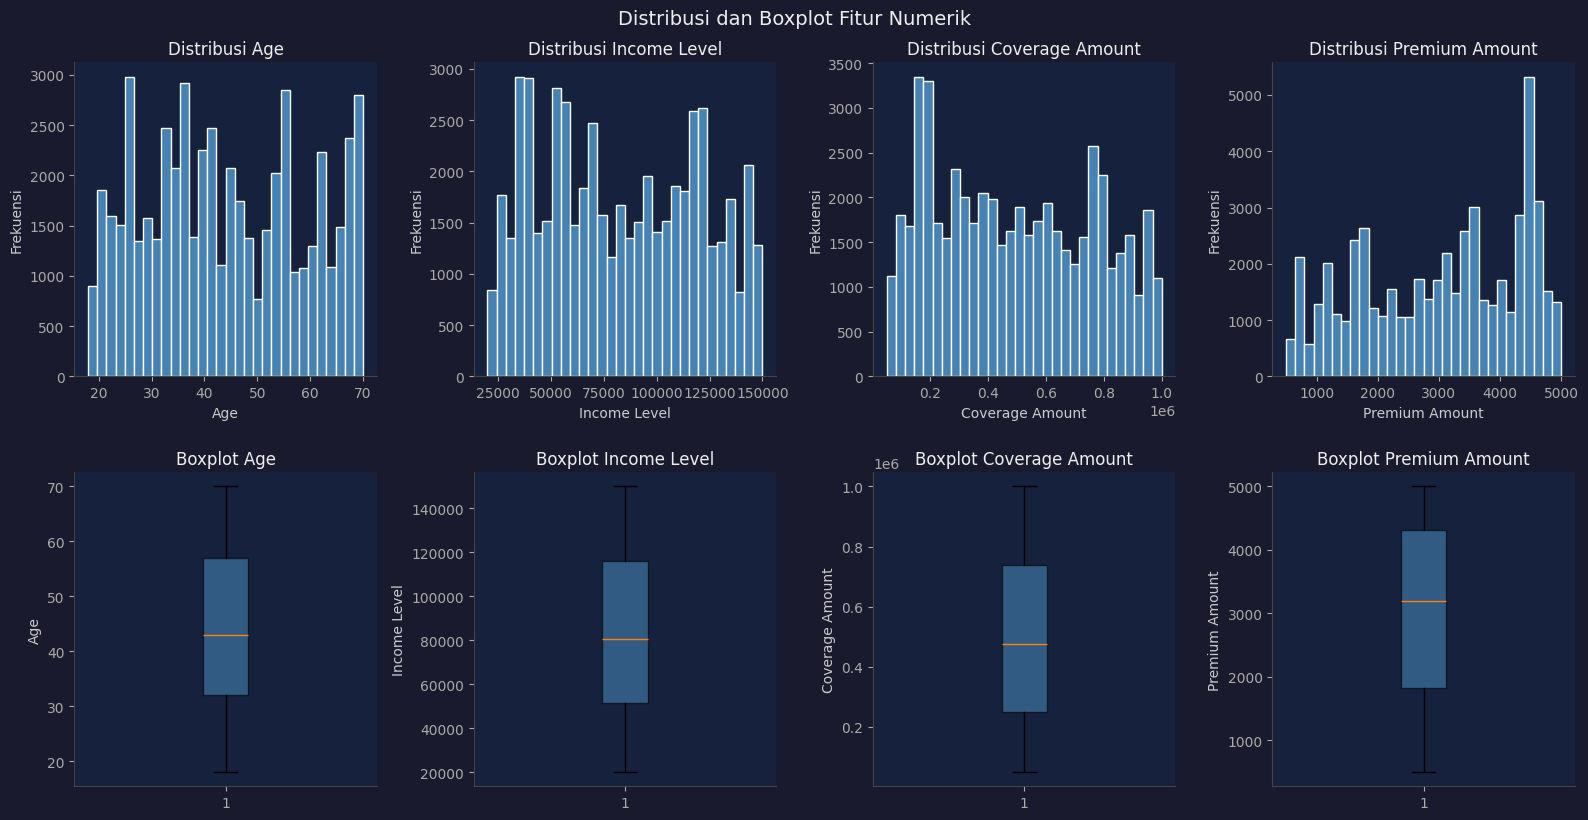

In [ ]:
num_cols = ['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'Distribusi {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[1, i].set_title(f'Boxplot {col}')
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Distribusi dan Boxplot Fitur Numerik', y=1.02, fontsize=14)
plt.show()

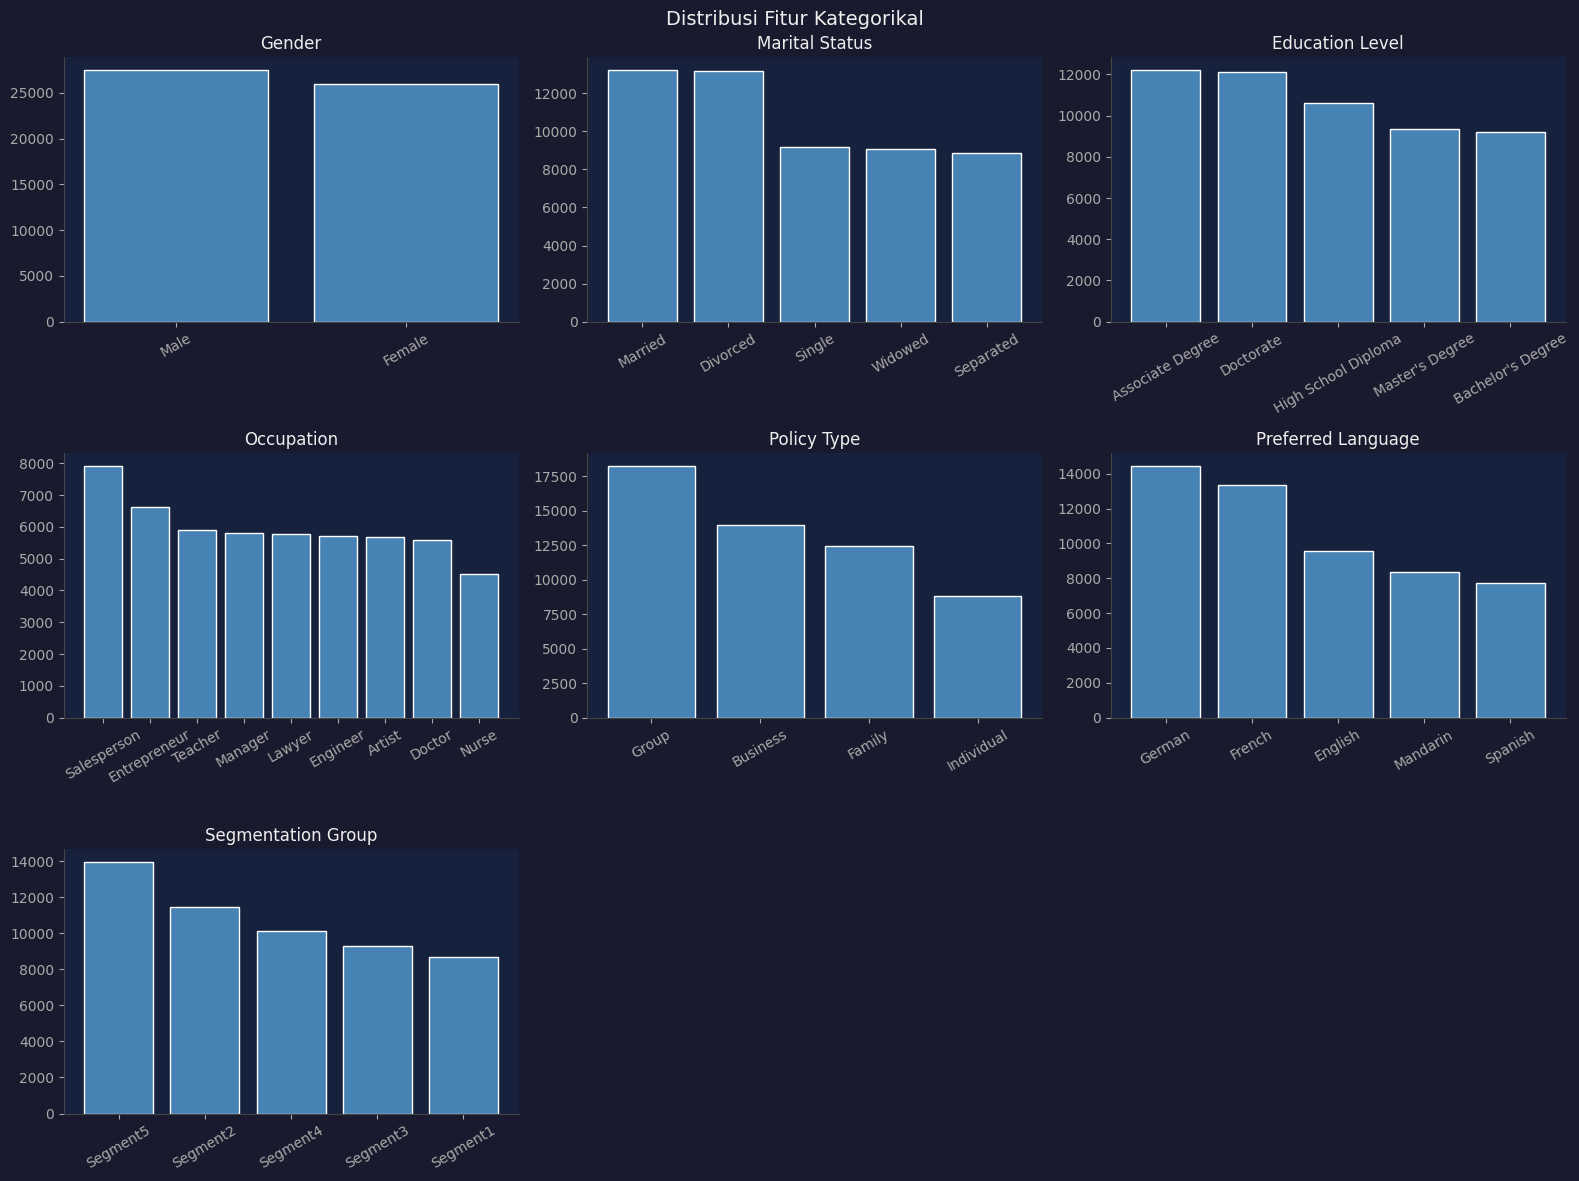

In [ ]:
cat_cols = ['Gender', 'Marital Status', 'Education Level', 'Occupation',
            'Policy Type', 'Preferred Language', 'Segmentation Group']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14)
plt.tight_layout()
plt.show()

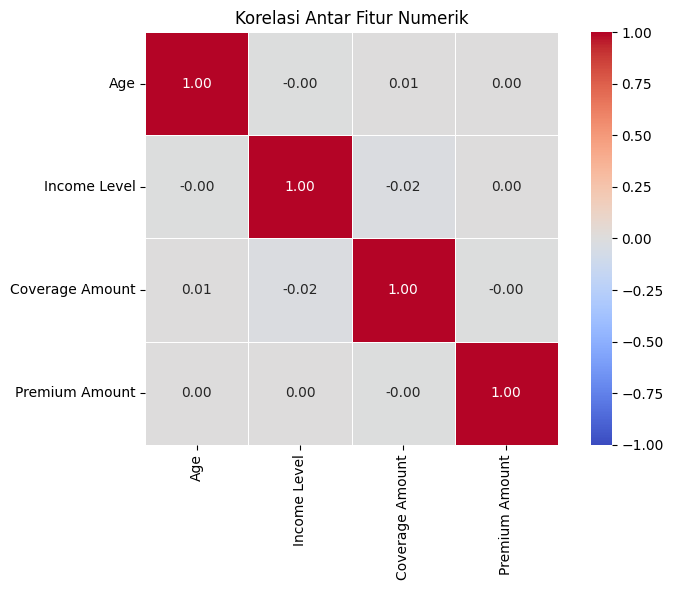

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

=== Distribusi Segmentation Group (Label Referensi) ===
Segmentation Group
Segment5    13976
Segment2    11442
Segment4    10125
Segment3     9277
Segment1     8683
Name: count, dtype: int64


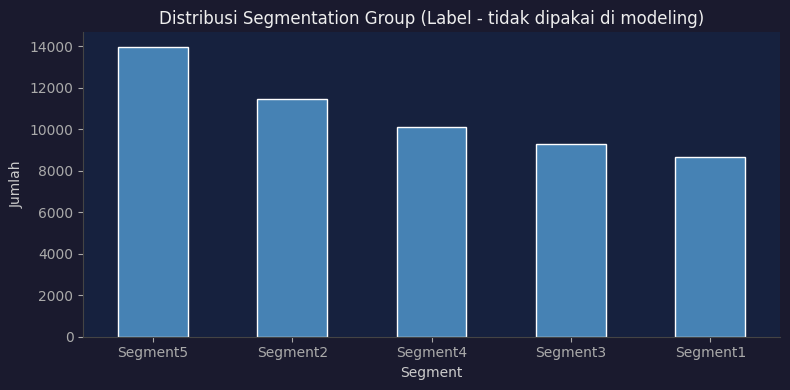

In [ ]:
print('=== Distribusi Segmentation Group (Label Referensi) ===')
print(df['Segmentation Group'].value_counts())

plt.figure(figsize=(8, 4))
df['Segmentation Group'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Distribusi Segmentation Group (Label - tidak dipakai di modeling)')
plt.xlabel('Segment')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language,Segmentation Group
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English,Segment5
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French,Segment5
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German,Segment3
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French,Segment3
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English,Segment2


#Prepare Data - Preprocessing

In [ ]:
df_clustering = df[['Age', 'Income Level', 'Coverage Amount', 'Premium Amount', 'Marital Status','Gender']]

In [ ]:
num_cols = df_clustering.select_dtypes(include=['int64']).columns
cat_cols = df_clustering.select_dtypes(include=['object']).columns

print("Numerical Columns:\n", num_cols)
print("\nCategorical Columns:\n", cat_cols)

Numerical Columns:
 Index(['Age', 'Income Level', 'Coverage Amount', 'Premium Amount'], dtype='object')

Categorical Columns:
 Index(['Marital Status', 'Gender'], dtype='object')


In [ ]:
df_encoded = pd.get_dummies(df_clustering, columns=cat_cols, drop_first=True)

df_encoded.head()

# cat_cols_model = df_clustering.select_dtypes(include='object').columns.tolist()
# print('Kolom kategorikal yang di-encode:', cat_cols_model)

# df_encoded = df_clustering.copy()
# le_dict = {}

# for col in cat_cols_model:
#     le = LabelEncoder()
#     df_encoded[col] = le.fit_transform(df_encoded[col])
#     le_dict[col] = le

# print(f'\nShape setelah encoding: {df_encoded.shape}')
# df_encoded.head(3)

,Age,Income Level,Coverage Amount,Premium Amount,Marital Status_Married,Marital Status_Separated,Marital Status_Single,Marital Status_Widowed,Gender_Male
0,23,70541,366603,2749,True,False,False,False,False
1,26,54168,780236,1966,False,False,False,True,True
2,29,73899,773926,4413,False,False,True,False,False
3,20,63381,787815,4342,False,False,False,False,True
4,25,38794,366506,1276,False,True,False,False,False


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f'Shape data setelah scaling: {X_scaled.shape}')
print(f'Mean per fitur (seharusnya ~0): {X_scaled.mean(axis=0).round(3)}')
print(f'Std per fitur (seharusnya ~1): {X_scaled.std(axis=0).round(3)}')

Shape data setelah scaling: (53503, 9)
Mean per fitur (seharusnya ~0): [-0. -0.  0.  0. -0. -0. -0.  0.  0.]
Std per fitur (seharusnya ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


#Build

k=2 | Inertia: 417237.02
k=3 | Inertia: 358888.21
k=4 | Inertia: 305370.73
k=5 | Inertia: 267296.01
k=6 | Inertia: 254101.37
k=7 | Inertia: 243797.21
k=8 | Inertia: 234603.86
k=9 | Inertia: 227625.19
k=10 | Inertia: 218640.62


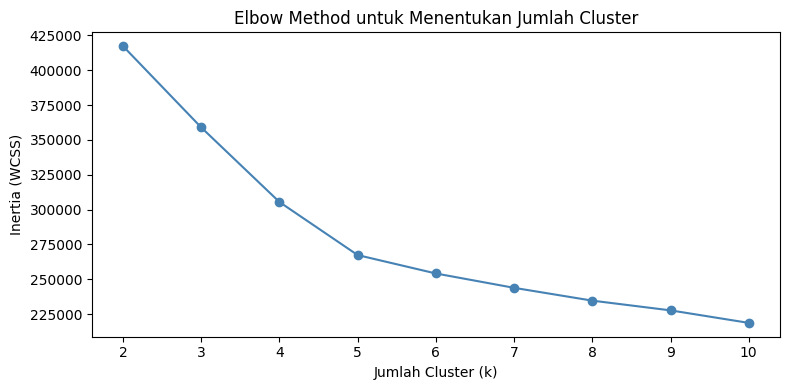

In [ ]:
inertia_list = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    inertia_list.append(km.inertia_)
    print(f'k={k} | Inertia: {km.inertia_:.2f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertia_list, marker='o', color='steelblue')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method untuk Menentukan Jumlah Cluster')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

k=2 | Silhouette Score: 0.1404
k=3 | Silhouette Score: 0.1954
k=4 | Silhouette Score: 0.2393
k=5 | Silhouette Score: 0.2387
k=6 | Silhouette Score: 0.1992
k=7 | Silhouette Score: 0.1971
k=8 | Silhouette Score: 0.1970
k=9 | Silhouette Score: 0.1894
k=10 | Silhouette Score: 0.1873


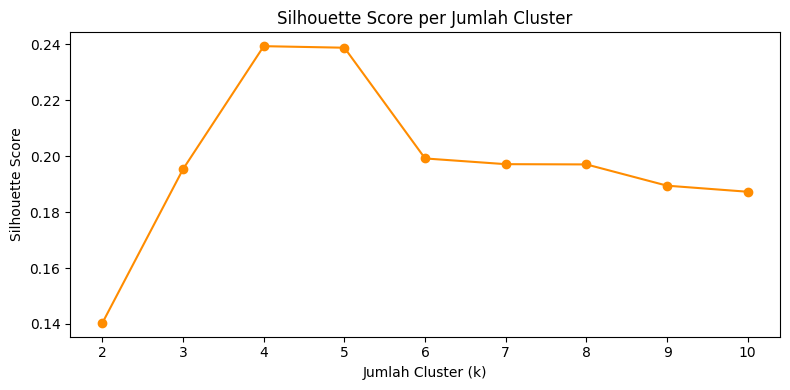

In [ ]:
# Silhouette Score untuk setiap k
silhouette_list = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_list.append(sil)
    print(f'k={k} | Silhouette Score: {sil:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), silhouette_list, marker='o', color='darkorange')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score per Jumlah Cluster')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

In [ ]:
BEST_K = 5

kmeans = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

print(f'K-Means selesai dengan k={BEST_K}')
print(f'Iterasi konvergensi: {kmeans.n_iter_}')
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} data ({c/len(cluster_labels)*100:.1f}%)')

K-Means selesai dengan k=5
Iterasi konvergensi: 8
  Cluster 0: 9077 data (17.0%)
  Cluster 1: 13151 data (24.6%)
  Cluster 2: 13219 data (24.7%)
  Cluster 3: 8861 data (16.6%)
  Cluster 4: 9195 data (17.2%)


#Evaluation

In [ ]:
sil_score = silhouette_score(X_scaled, cluster_labels, sample_size=5000, random_state=42)
db_score = davies_bouldin_score(X_scaled, cluster_labels)
ch_score = calinski_harabasz_score(X_scaled, cluster_labels)

print('=== Evaluasi Model K-Means ===')
print(f'Silhouette Score        : {sil_score:.4f}  (semakin tinggi semakin baik, max=1)')
print(f'Davies-Bouldin Score    : {db_score:.4f}  (semakin rendah semakin baik, min=0)')
print(f'Calinski-Harabasz Score : {ch_score:.2f}  (semakin tinggi semakin baik)')
print(f'Inertia (WCSS)          : {kmeans.inertia_:.2f}')

=== Evaluasi Model K-Means ===
Silhouette Score        : 0.2387  (semakin tinggi semakin baik, max=1)
Davies-Bouldin Score    : 1.7497  (semakin rendah semakin baik, min=0)
Calinski-Harabasz Score : 10719.32  (semakin tinggi semakin baik)
Inertia (WCSS)          : 267296.01


Variance explained by 2 PC: 27.88%


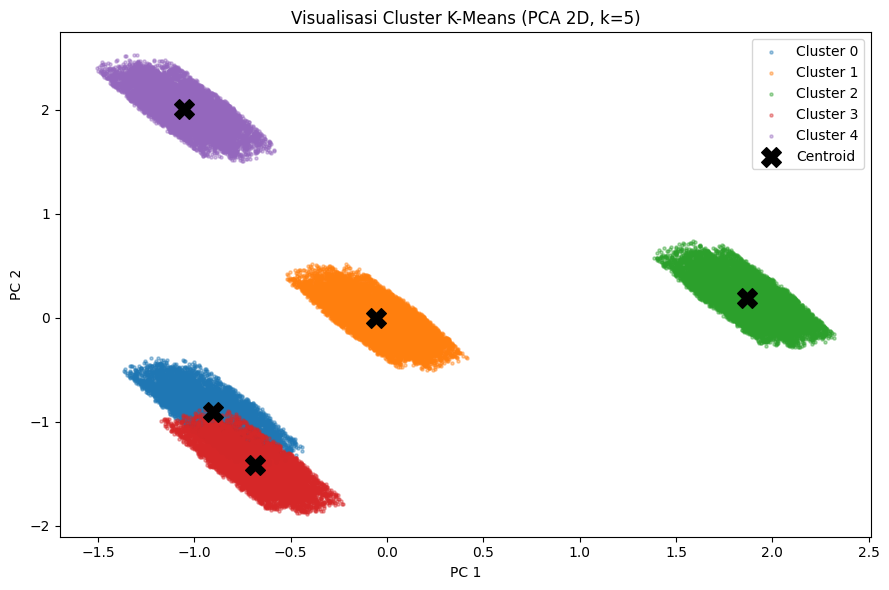

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Variance explained by 2 PC: {pca.explained_variance_ratio_.sum()*100:.2f}%')

plt.figure(figsize=(9, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(BEST_K):
    mask = cluster_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, alpha=0.4,
                color=colors[i], label=f'Cluster {i}')

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=200, marker='X', c='black', zorder=5, label='Centroid')

plt.title(f'Visualisasi Cluster K-Means (PCA 2D, k={BEST_K})')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.tight_layout()
plt.show()

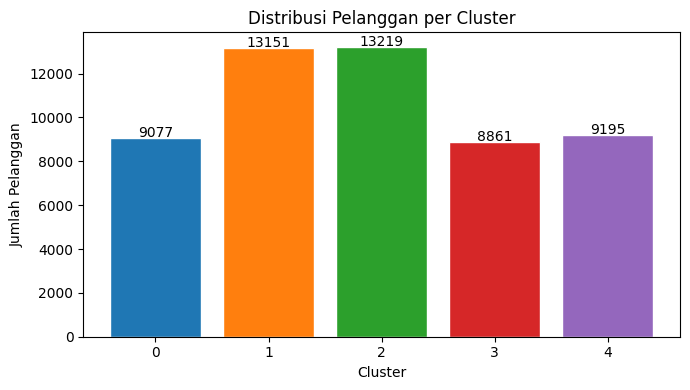

In [ ]:
df_result = df.copy()
df_result['Cluster'] = cluster_labels

cluster_counts = df_result['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='white')
for i, v in zip(cluster_counts.index, cluster_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)
plt.xlabel('Cluster')
plt.ylabel('Jumlah Pelanggan')
plt.title('Distribusi Pelanggan per Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Profil numerik tiap cluster
num_profile = df_result.groupby('Cluster')[['Age', 'Income Level', 'Coverage Amount', 'Premium Amount']].mean().round(1)
print('=== Rata-rata Fitur Numerik per Cluster ===')
print(num_profile.to_string())

=== Rata-rata Fitur Numerik per Cluster ===
          Age  Income Level  Coverage Amount  Premium Amount
Cluster                                                     
0        44.0       82712.9         487849.9          3014.2
1        44.2       82495.2         494298.6          3018.9
2        44.1       84049.7         500663.9          3073.0
3        44.3       83833.7         486240.4          3062.9
4        44.2       80344.8         489283.7          2931.2


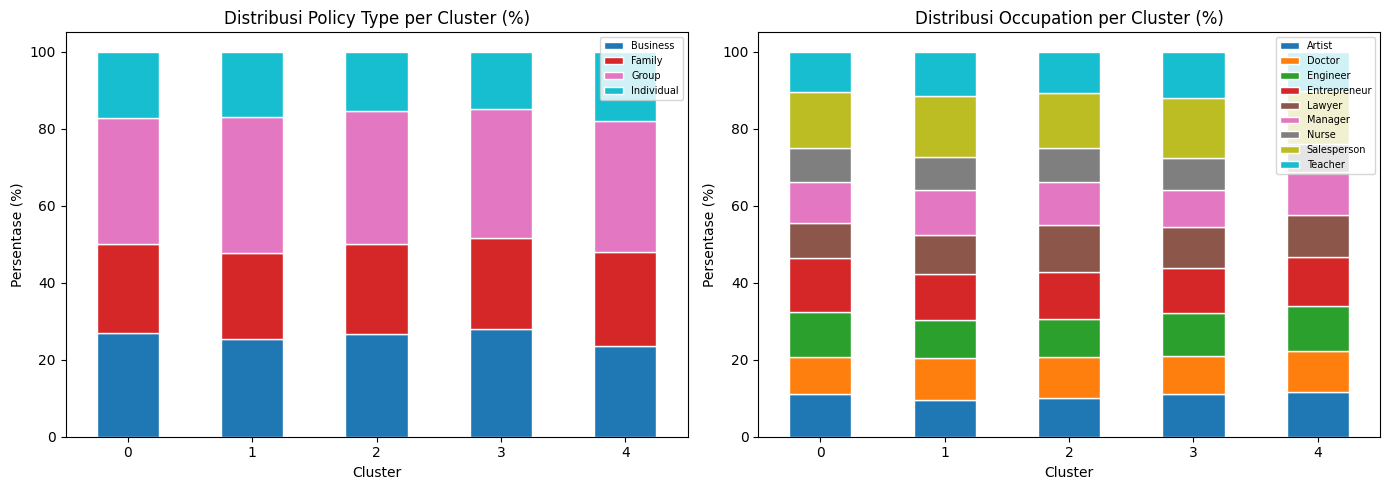

In [ ]:
# Distribusi Policy Type dan Occupation per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Policy Type', 'Occupation']):
    ct = pd.crosstab(df_result['Cluster'], df_result[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white')
    ax.set_title(f'Distribusi {col} per Cluster (%)')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Persentase (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.show()

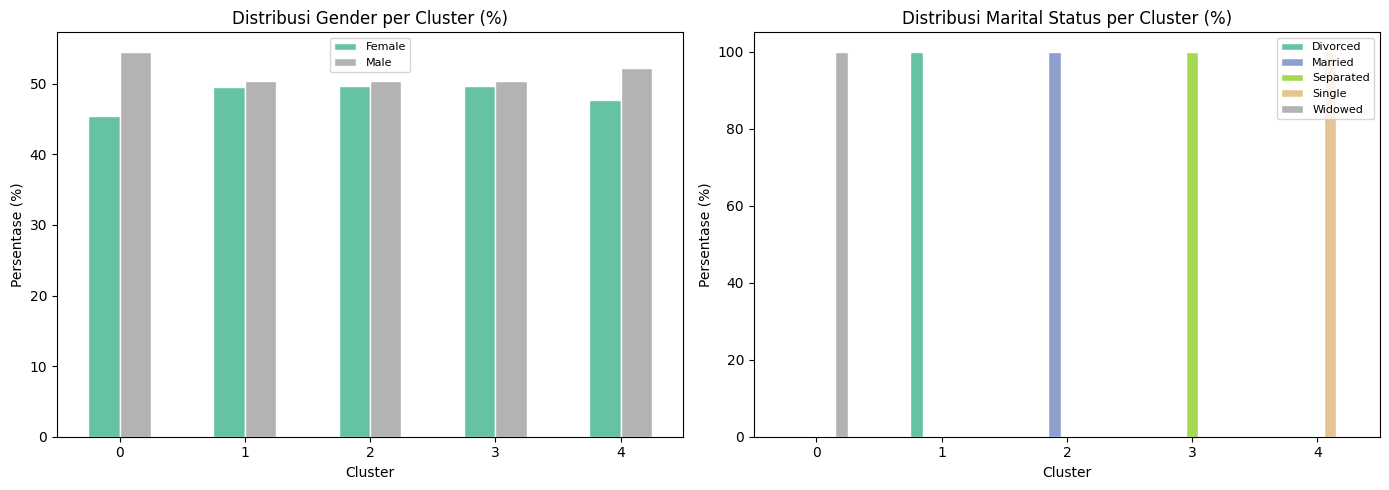

In [ ]:
# Distribusi Gender dan Marital Status per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Gender', 'Marital Status']):
    ct = pd.crosstab(df_result['Cluster'], df_result[col], normalize='index') * 100
    ct.plot(kind='bar', stacked=False, ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'Distribusi {col} per Cluster (%)')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Persentase (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

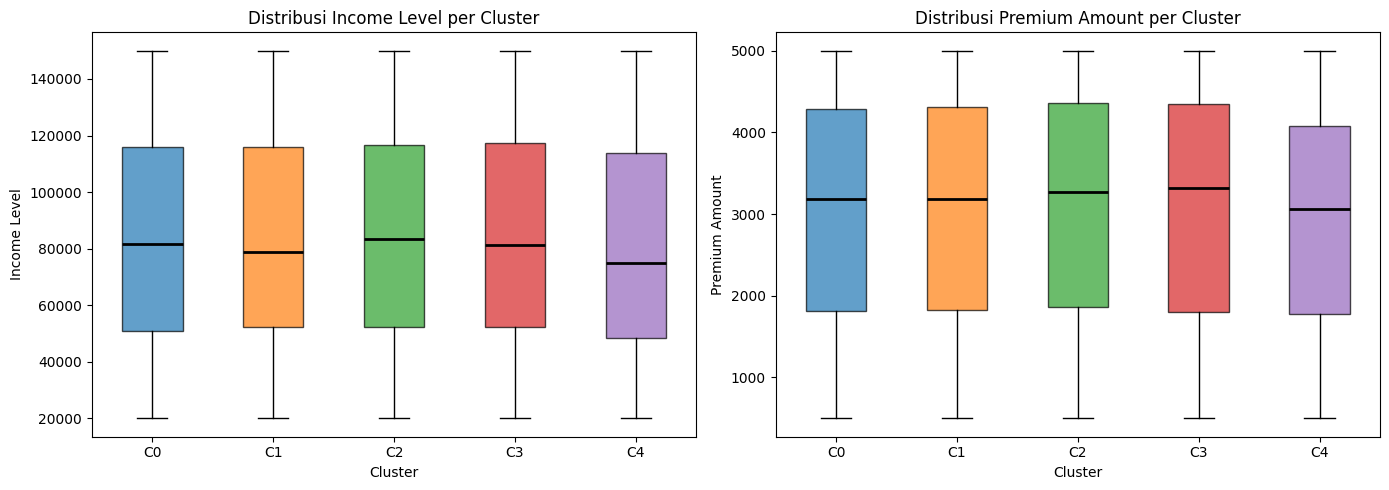

In [ ]:
# Boxplot Income Level dan Premium Amount per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['Income Level', 'Premium Amount']):
    data_by_cluster = [df_result[df_result['Cluster'] == k][col].values for k in range(BEST_K)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True,
                    boxprops=dict(alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_xticklabels([f'C{k}' for k in range(BEST_K)])
    ax.set_title(f'Distribusi {col} per Cluster')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

#Communication

In [ ]:
# Ringkasan profil tiap cluster
summary = df_result.groupby('Cluster').agg(
    Jumlah_Pelanggan=('Age', 'count'),
    Rata_Usia=('Age', 'mean'),
    Rata_Income=('Income Level', 'mean'),
    Rata_Coverage=('Coverage Amount', 'mean'),
    Rata_Premium=('Premium Amount', 'mean')
).round(1)

summary['% Pelanggan'] = (summary['Jumlah_Pelanggan'] / len(df_result) * 100).round(1)
print('=== Ringkasan Profil Cluster ===')
print(summary.to_string())

=== Ringkasan Profil Cluster ===
         Jumlah_Pelanggan  Rata_Usia  Rata_Income  Rata_Coverage  Rata_Premium  % Pelanggan
Cluster                                                                                    
0                    9077       44.0      82712.9       487849.9        3014.2         17.0
1                   13151       44.2      82495.2       494298.6        3018.9         24.6
2                   13219       44.1      84049.7       500663.9        3073.0         24.7
3                    8861       44.3      83833.7       486240.4        3062.9         16.6
4                    9195       44.2      80344.8       489283.7        2931.2         17.2


In [ ]:
# Labeling cluster berdasarkan karakteristik dominan
cluster_names = {}
for cluster_id in range(BEST_K):
    sub = df_result[df_result['Cluster'] == cluster_id]
    avg_income = sub['Income Level'].mean()
    avg_age = sub['Age'].mean()
    avg_premium = sub['Premium Amount'].mean()

    # Label sederhana berdasarkan income
    overall_income_mean = df_result['Income Level'].mean()
    income_label = 'High Income' if avg_income > overall_income_mean * 1.05 else \
                   ('Low Income' if avg_income < overall_income_mean * 0.95 else 'Mid Income')
    age_label = 'Muda' if avg_age < 35 else ('Senior' if avg_age > 55 else 'Dewasa')

    label = f'{age_label} - {income_label}'
    cluster_names[cluster_id] = label
    print(f'Cluster {cluster_id}: {label} | Usia={avg_age:.1f} | Income={avg_income:.0f} | Premium={avg_premium:.0f}')

df_result['Cluster Label'] = df_result['Cluster'].map(cluster_names)

Cluster 0: Dewasa - Mid Income | Usia=44.0 | Income=82713 | Premium=3014
Cluster 1: Dewasa - Mid Income | Usia=44.2 | Income=82495 | Premium=3019
Cluster 2: Dewasa - Mid Income | Usia=44.1 | Income=84050 | Premium=3073
Cluster 3: Dewasa - Mid Income | Usia=44.3 | Income=83834 | Premium=3063
Cluster 4: Dewasa - Mid Income | Usia=44.2 | Income=80345 | Premium=2931


=== Perbandingan Cluster K-Means vs Segmentation Group Asli ===
Segmentation Group  Segment1  Segment2  Segment3  Segment4  Segment5
Cluster                                                             
0                       1465      1948      1607      1727      2330
1                       2136      2739      2040      2479      3757
2                       2098      2884      2098      2445      3694
3                       1561      2008      1658      1703      1931
4                       1423      1863      1874      1771      2264


<Figure size 900x500 with 0 Axes>

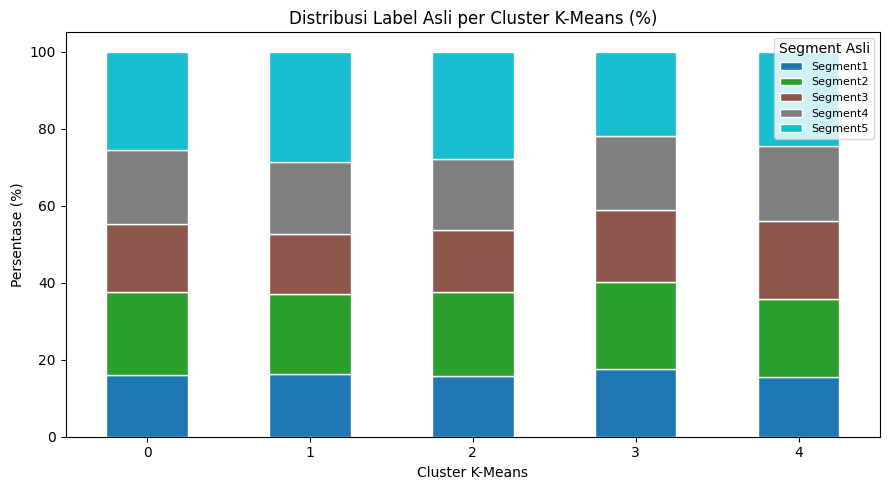

In [ ]:
# Perbandingan distribusi cluster hasil K-Means vs label asli
print('=== Perbandingan Cluster K-Means vs Segmentation Group Asli ===')
ct_comparison = pd.crosstab(df_result['Cluster'], df_result['Segmentation Group'])
print(ct_comparison)

plt.figure(figsize=(9, 5))
ct_comparison_norm = ct_comparison.div(ct_comparison.sum(axis=1), axis=0) * 100
ct_comparison_norm.plot(kind='bar', stacked=True, colormap='tab10', edgecolor='white',
                        figsize=(9, 5))
plt.title('Distribusi Label Asli per Cluster K-Means (%)')
plt.xlabel('Cluster K-Means')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Segment Asli', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Rekomendasi strategi bisnis
print('=== INSIGHT DAN REKOMENDASI STRATEGI BISNIS ===')
print()

for cluster_id in range(BEST_K):
    sub = df_result[df_result['Cluster'] == cluster_id]
    n = len(sub)
    avg_income = sub['Income Level'].mean()
    avg_premium = sub['Premium Amount'].mean()
    avg_coverage = sub['Coverage Amount'].mean()
    avg_age = sub['Age'].mean()
    top_policy = sub['Policy Type'].mode()[0]
    top_channel = sub['Preferred Communication Channel'].mode()[0]

    print(f'--- Cluster {cluster_id} | {cluster_names[cluster_id]} | {n} pelanggan ({n/len(df_result)*100:.1f}%) ---')
    print(f'  Rata-rata Usia     : {avg_age:.0f} tahun')
    print(f'  Rata-rata Income   : {avg_income:,.0f}')
    print(f'  Rata-rata Premium  : {avg_premium:,.0f}')
    print(f'  Rata-rata Coverage : {avg_coverage:,.0f}')
    print(f'  Policy Terpopuler  : {top_policy}')
    print(f'  Channel Preferensi : {top_channel}')

    # Rekomendasi otomatis
    if avg_income > df_result['Income Level'].mean() * 1.05:
        print(f'  >> Rekomendasi: Tawarkan produk asuransi premium dan coverage tinggi. Prioritaskan upselling.')
    elif avg_income < df_result['Income Level'].mean() * 0.95:
        print(f'  >> Rekomendasi: Fokus pada produk entry-level dengan premi terjangkau. Berikan program loyalitas.')
    else:
        print(f'  >> Rekomendasi: Pertahankan hubungan dengan penawaran paket bundling yang relevan.')
    print()

=== INSIGHT DAN REKOMENDASI STRATEGI BISNIS ===

--- Cluster 0 | Dewasa - Mid Income | 9077 pelanggan (17.0%) ---
  Rata-rata Usia     : 44 tahun
  Rata-rata Income   : 82,713
  Rata-rata Premium  : 3,014
  Rata-rata Coverage : 487,850
  Policy Terpopuler  : Group
  Channel Preferensi : In-Person Meeting
  >> Rekomendasi: Pertahankan hubungan dengan penawaran paket bundling yang relevan.

--- Cluster 1 | Dewasa - Mid Income | 13151 pelanggan (24.6%) ---
  Rata-rata Usia     : 44 tahun
  Rata-rata Income   : 82,495
  Rata-rata Premium  : 3,019
  Rata-rata Coverage : 494,299
  Policy Terpopuler  : Group
  Channel Preferensi : In-Person Meeting
  >> Rekomendasi: Pertahankan hubungan dengan penawaran paket bundling yang relevan.

--- Cluster 2 | Dewasa - Mid Income | 13219 pelanggan (24.7%) ---
  Rata-rata Usia     : 44 tahun
  Rata-rata Income   : 84,050
  Rata-rata Premium  : 3,073
  Rata-rata Coverage : 500,664
  Policy Terpopuler  : Group
  Channel Preferensi : In-Person Meeting
  >> R

In [ ]:
# Simpan hasil clustering
output = df.copy()
output['Cluster'] = cluster_labels
output['Cluster Label'] = df_result['Cluster Label']
output.to_csv('customer_segmentation_result.csv', index=False)
print('Hasil clustering tersimpan di: customer_segmentation_result.csv')
print(f'Total pelanggan yang tersegmentasi: {len(output)}')

Hasil clustering tersimpan di: customer_segmentation_result.csv
Total pelanggan yang tersegmentasi: 53503
